# Thư viện

In [37]:
import warnings
warnings.simplefilter('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import sys
from pathlib import Path

# Dữ liệu

In [38]:
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from utils.motherduck import connect_motherduck
from utils.sql import query_dataframe

connection = connect_motherduck(read_only=True)

In [39]:
# Row count
row_counts = query_dataframe(
    connection,
    """
    select 'silver_listings' as dataset, count(*) as rows
    from airbnb_analytics.silver.silver_listings
    union all
    select 'silver_calendar', count(*)
    from airbnb_analytics.silver.silver_calendar
    union all
    select 'silver_reviews', count(*)
    from airbnb_analytics.silver.silver_reviews
    union all
    select 'silver_neighbourhoods', count(*)
    from airbnb_analytics.silver.silver_neighbourhoods
    """
)

row_counts

,dataset,rows
0,silver_listings,28806
1,silver_calendar,10514202
2,silver_reviews,583333
3,silver_neighbourhoods,50


In [40]:
# Dữ liệu listings
listings_eda = query_dataframe(
    connection,
    """
    select
        listing_id,
        -- location
        neighbourhood,
        latitude,
        longitude,

        -- listing attributes
        property_type,
        room_type,
        accommodates,
        bathrooms,
        bedrooms,
        beds,
        -- pricing rules
        price,
        minimum_nights,
        maximum_nights,
        instant_bookable,

        -- host attributes
        host_id,
        host_since,
        host_response_time,
        host_response_rate,
        host_acceptance_rate,
        host_is_superhost,
        host_identity_verified,
        host_listings_count,
        host_total_listings_count,
        calculated_host_listings_count,

        -- availability
        availability_30,
        availability_60,
        availability_90,
        availability_365,

        -- reviews
        number_of_reviews,
        number_of_reviews_ltm,
        last_review,
        reviews_per_month,

        -- review scores
        review_scores_rating,
        review_scores_accuracy,
        review_scores_cleanliness,
        review_scores_checkin,
        review_scores_communication,
        review_scores_location,
        review_scores_value

    from airbnb_analytics.silver.silver_listings
    order by listing_id
    """
)

listings_eda.head()

,listing_id,neighbourhood,latitude,longitude,property_type,room_type,accommodates,bathrooms,bedrooms,beds,...,number_of_reviews_ltm,last_review,reviews_per_month,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value
0,27934,Ratchathewi,13.75983,100.54134,Entire condo,Entire home/apt,2,1.5,1.0,1.0,...,0,2024-09-17,0.40,4.86,4.95,4.82,4.97,4.91,4.66,4.75
1,27979,Bang Na,13.66818,100.61674,Private room in rental unit,Private room,2,1.0,NaN,NaN,...,0,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,28745,Bang Kapi,13.75232,100.62402,Private room in rental unit,Private room,2,1.0,1.0,NaN,...,0,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,47516,Don Mueang,13.92726,100.58529,Entire home,Entire home/apt,1,NaN,4.0,1.0,...,0,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,48736,Rat Burana,13.68556,100.49535,Private room in rental unit,Private room,2,1.0,1.0,1.0,...,0,2014-02-03,0.01,5.00,5.00,5.00,5.00,5.00,5.00,5.00


# EDA

In [41]:
# Tổng quan về dữ liệu
listings_eda.describe(include="number").T

,count,mean,std,min,25%,50%,75%,max
listing_id,28806.0,799504135292119296.0,578611715967888128.0,27934.0,40217193.5,994658278891122688.0,1314730451711460864.0,1518168294097881344.0
latitude,28806.0,13.744811,0.040952,13.52937,13.720365,13.73955,13.758728,13.95354
longitude,28806.0,100.562735,0.049999,100.328924,100.53098,100.56604,100.585742,100.92371
accommodates,28806.0,3.137541,2.275833,1.0,2.0,2.0,4.0,16.0
bathrooms,28655.0,1.390578,1.191579,0.0,1.0,1.0,1.0,50.0
bedrooms,27502.0,1.41797,1.406303,0.0,1.0,1.0,1.0,50.0
beds,23224.0,1.820961,1.835147,0.0,1.0,1.0,2.0,50.0
price,23273.0,2528.749151,16473.896035,4.0,923.0,1379.0,2207.0,1000000.0
minimum_nights,28806.0,14.107373,43.243299,1.0,1.0,2.0,14.0,1115.0
maximum_nights,28806.0,489.5243,897.307655,1.0,365.0,365.0,365.0,100000.0


In [42]:
# Check missing values
missing = listings_eda.isna().mean().sort_values(ascending=False) * 100
missing[missing > 0]

review_scores_value            35.048254
review_scores_location         35.041311
review_scores_checkin          35.037839
review_scores_cleanliness      35.030896
review_scores_communication    35.030896
reviews_per_month              35.027425
last_review                    35.027425
review_scores_rating           35.027425
review_scores_accuracy         35.027425
host_response_rate             19.603555
beds                           19.377907
price                          19.207804
host_acceptance_rate           14.854544
host_is_superhost               5.589113
bedrooms                        4.526835
bathrooms                       0.524196
host_response_time              0.031243
host_identity_verified          0.031243
host_listings_count             0.031243
host_total_listings_count       0.031243
host_since                      0.031243
dtype: float64

**Nhận xét:** 
- Nhóm review missing khoảng 35% hoặc Nhóm Host response khoảng 15 - 20% do nguyên nhân nghiệp vụ. 
- Nhóm Price 19% bất thường, tuy nhiên vẫn đủ để huấn luyện mô hình. Thực hiện loại bỏ các dòng null. 

In [43]:
listings_eda[
    listings_eda["price"].isna()
].head()

,listing_id,neighbourhood,latitude,longitude,property_type,room_type,accommodates,bathrooms,bedrooms,beds,...,number_of_reviews_ltm,last_review,reviews_per_month,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value
1,27979,Bang Na,13.66818,100.61674,Private room in rental unit,Private room,2,1.0,NaN,NaN,...,0,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,28745,Bang Kapi,13.75232,100.62402,Private room in rental unit,Private room,2,1.0,1.0,NaN,...,0,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,62217,Phaya Thai,13.79152,100.53982,Private room in home,Private room,2,1.0,NaN,NaN,...,0,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12,159355,Yan na wa,13.71363,100.54652,Entire condo,Entire home/apt,2,1.0,1.0,NaN,...,0,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
13,169285,Huai Khwang,13.78118,100.58349,Private room in rental unit,Private room,3,1.0,1.0,NaN,...,0,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [44]:
# Kiểm tra số dòng trước khi loại
print("Before:", listings_eda.shape)

# Loại các dòng thiếu target price
listings_v2 = listings_eda.dropna(subset=["price"]).copy()

# Kiểm tra sau khi loại
print("After:", listings_v2.shape)

# Kiểm tra còn missing price không
print("Missing price:", listings_v2["price"].isna().sum())

Before: (28806, 39)
After: (23273, 39)
Missing price: 0


## Biến target: Price

In [45]:
listings_v2["price"].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])

count      23273.000000
mean        2528.749151
std        16473.896035
min            4.000000
1%           340.720000
5%           549.000000
25%          923.000000
50%         1379.000000
75%         2207.000000
95%         6000.000000
99%        16669.600000
max      1000000.000000
Name: price, dtype: float64

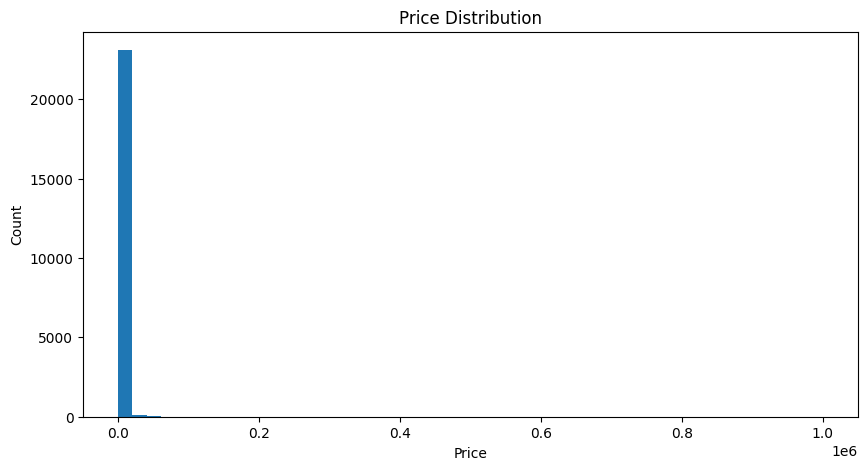

In [46]:
plt.figure(figsize=(10, 5))
plt.hist(listings_v2["price"], bins=50)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

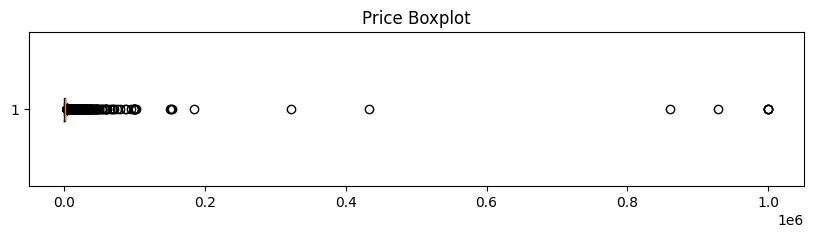

In [47]:
plt.figure(figsize=(10, 2))

plt.boxplot(
    listings_v2["price"].dropna(),
    vert=False
)

plt.title("Price Boxplot")
plt.show()

Nhận xét về biến target `price`:
- Phân phối lệch phải mạnh
- Khoảng giá từ 923 - 2.207 THB
- Cân nhắc biến đổi log để giảm ảnh hưởng của outlier lên mô hình

In [48]:
listings_eda["log_price"] = np.log1p(listings_eda["price"])

<Axes: >

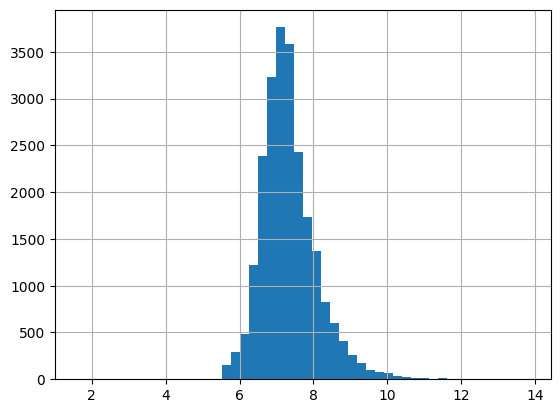

In [49]:
listings_eda["log_price"].hist(bins=50)

## Tổng quan về chất lượng dữ liệu

In [50]:
# Check missing values
missing = listings_v2.isna().mean().sort_values(ascending=False) * 100
missing[missing > 0]

review_scores_value            30.765264
review_scores_checkin          30.760968
review_scores_communication    30.760968
review_scores_location         30.760968
review_scores_rating           30.756671
review_scores_accuracy         30.756671
review_scores_cleanliness      30.756671
reviews_per_month              30.756671
last_review                    30.756671
host_response_rate             11.842049
host_acceptance_rate            7.399132
host_is_superhost               6.333520
bedrooms                        0.378121
bathrooms                       0.257809
beds                            0.227732
host_since                      0.030078
host_total_listings_count       0.030078
host_identity_verified          0.030078
host_listings_count             0.030078
host_response_time              0.030078
dtype: float64

### Nhóm review ~ 30.76%

In [51]:
(
    listings_v2["number_of_reviews"] == 0
).mean()

np.float64(0.30756670820263826)

**Nhận xét:**
- Khoảng 30,76% listing không có thông tin đánh giá, tần suất và thời gian đánh giá gần nhất. Sau khi kiểm tra biến 
`number_of_reviews` cho thấy tỷ lệ listing chưa từng nhận đánh giá đúng bằng 30,76%. Điều này cho thấy giá trị thiếu phản ánh trạng thái nghiệp vụ.
- Thực hiện fill 0.

In [52]:
# Fill 0 cho giá trị thiếu nhóm review
review_columns = [
    "review_scores_rating",
    "review_scores_accuracy",
    "review_scores_cleanliness",
    "review_scores_checkin",
    "review_scores_communication",
    "review_scores_location",
    "review_scores_value"
]

listings_v2[review_columns] = (
    listings_v2[review_columns]
    .fillna(0)
)

listings_v2["reviews_per_month"] = (
    listings_v2["reviews_per_month"]
    .fillna(0)
)

### Nhóm host ~ 0 - 11%

In [53]:
# Chiếm  ~ 0% nên loại bỏ để làm sạch dữ liệu
listings_v2 = listings_v2.dropna(
    subset=[
        "host_since",
        "host_total_listings_count",
        "host_identity_verified",
        "host_listings_count",
        "host_response_time"
    ]
)

In [54]:
# Fill median cho 7 - 11%
listings_v2["host_response_rate"] = (
    listings_v2["host_response_rate"]
    .fillna(listings_v2["host_response_rate"].median())
)

listings_v2["host_acceptance_rate"] = (
    listings_v2["host_acceptance_rate"]
    .fillna(listings_v2["host_acceptance_rate"].median())
)

In [55]:
# Fill f nếu thiếu host_is_superhost
# Fill missing bằng False
listings_v2["host_is_superhost"] = (
    listings_v2["host_is_superhost"]
    .fillna(False)
    .astype(int)
)

### Nhóm bedrooms, bathrooms, beds

In [56]:
# Thực hiện fill median theo nhóm room_type để giữ được sự khác biệt giữa các loại phòng
for col in ["bedrooms", "bathrooms", "beds"]:
    listings_v2[col] = listings_v2[col].fillna(
        listings_v2.groupby("room_type")[col]
        .transform("median")
    )

## Phân tích biến đặc trưng với biến target